# Data Loading

In [1]:
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_theme()



In [2]:
import kagglehub

path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [3]:
df = pd.read_csv(path + "/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# EDA (Exploratory Data Analysis)

## Dataset Overview

In [5]:
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
5143,5204-HMGYF,Female,0,Yes,Yes,49,Yes,No,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,87.20,4345,No
6800,1113-IUJYX,Female,0,Yes,No,14,Yes,No,Fiber optic,Yes,...,No,Yes,Yes,Yes,One year,No,Mailed check,105.95,1348.9,Yes
3630,9986-BONCE,Female,0,No,No,4,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),20.95,85.5,Yes
2456,5968-HYJRZ,Male,0,Yes,Yes,47,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,24.55,1160.45,No
522,0913-XWSCN,Male,0,Yes,Yes,55,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,No,Bank transfer (automatic),85.50,4713.4,No


In [6]:
df.shape

(7043, 21)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


The dataset contains 7,043 customer records and 21 columns, with no missing values reported at the metadata level. Most variables are categorical, while tenure, SeniorCitizen, and MonthlyCharges are numeric, which makes the dataset suitable for preprocessing before modeling. The TotalCharges column is stored as an object type and will likely require cleaning and conversion to numeric format. The target variable is Churn, which indicates whether a customer has left the service. It serves as the target label for supervised classification tasks, where the objective is to predict customer churn based on the available features.

## Column Analysis

In [8]:
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df.dropna(inplace=True)
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.to_list()
cat_cols = [col for col in df.select_dtypes(include=["object"]).columns if col != 'Churn']

target_col = 'Churn'

In [9]:
df.drop(columns=['customerID'], inplace=True)

In [10]:
df.duplicated().sum()

np.int64(22)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

gender: 2
SeniorCitizen: 2
Partner: 2
Dependents: 2
tenure: 72
PhoneService: 2
MultipleLines: 3
InternetService: 3
OnlineSecurity: 3
OnlineBackup: 3
DeviceProtection: 3
TechSupport: 3
StreamingTV: 3
StreamingMovies: 3
Contract: 3
PaperlessBilling: 2
PaymentMethod: 4
MonthlyCharges: 1584
TotalCharges: 6530
Churn: 2


##Target variable analysis

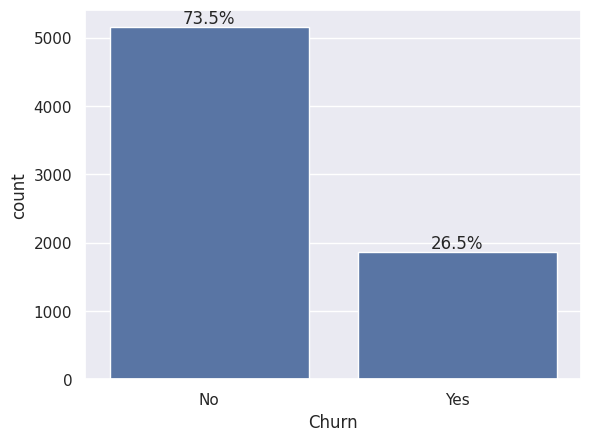

In [13]:
ax = sns.countplot(data=df, x="Churn")

total = len(df['Churn'])
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

The target variable is imbalanced, with the majority of customers belonging to the non-churn class. Specifically, 73.5% of customers did not churn, while only 26.5% churned. This imbalance should be considered during model training and evaluation, since accuracy alone may give a misleading picture of performance.

## Univariate Analysis

### Distribution Analysis using Boxplots

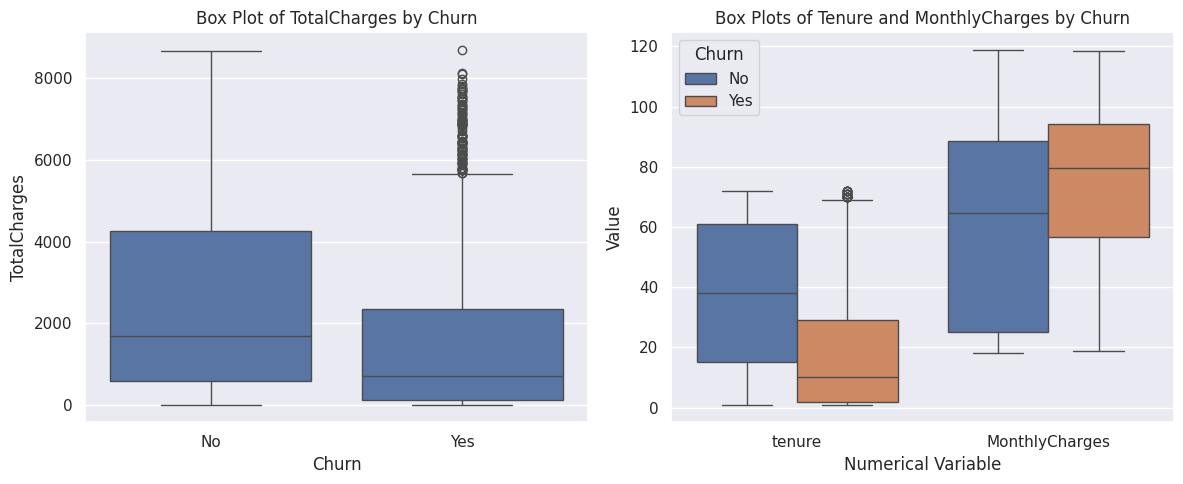

In [14]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='Churn', y='TotalCharges', data=df)
plt.title('Box Plot of TotalCharges by Churn')
plt.xlabel('Churn')
plt.ylabel('TotalCharges')

plt.subplot(1, 2, 2)
other_num_cols = [col for col in num_cols if col != 'TotalCharges']

df_melted_other_num_churn = df[other_num_cols + ['Churn']].melt(id_vars=['Churn'])
sns.boxplot(x="variable", y="value", hue='Churn', data=df_melted_other_num_churn)
plt.title('Box Plots of Tenure and MonthlyCharges by Churn')
plt.xlabel('Numerical Variable')
plt.ylabel('Value')

plt.tight_layout()

The chart shows that churned customers usually have lower tenure and higher MonthlyCharges. This may indicate that a shorter service duration and higher monthly costs are associated with a greater likelihood of churn. Their TotalCharges are also lower, which is consistent with a shorter relationship with the company.

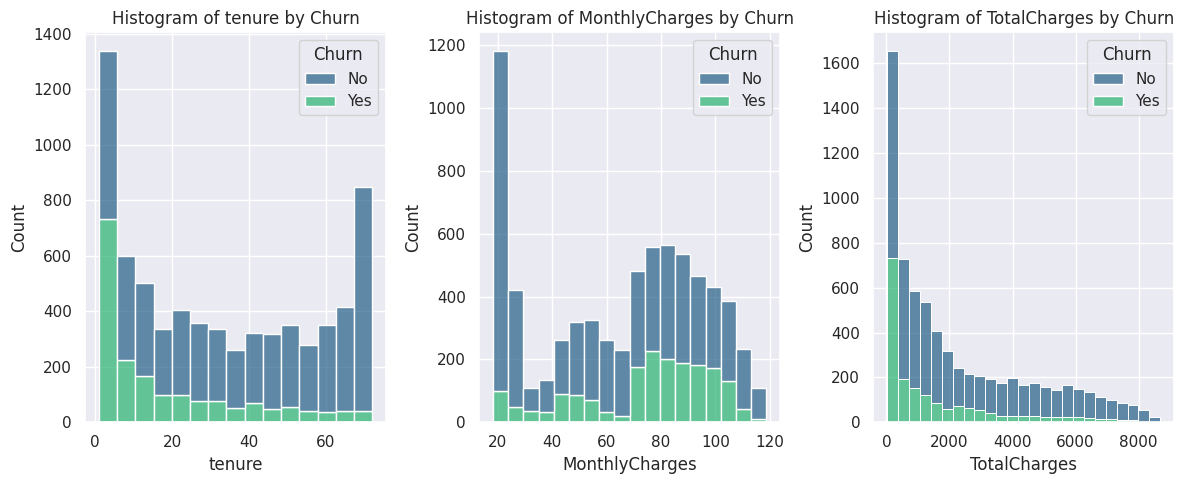

In [15]:
plt.figure(figsize=(12, 5))

for i, col in enumerate(num_cols):
    plt.subplot(1, 3, i + 1)
    sns.histplot(data=df, x=col, hue='Churn', palette='viridis', multiple='stack')
    plt.title(f'Histogram of {col} by Churn')
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()

The histograms show that the distributions of tenure, MonthlyCharges, and TotalCharges differ noticeably between churned and non-churned customers. Customers who stayed are more often associated with higher tenure and higher TotalCharges, while the churn group is concentrated at lower values, confirming the link between shorter customer lifetime and churn. For MonthlyCharges, churned customers appear more frequently in the higher charge range, suggesting that service cost may be one of the churn risk factors.

### Distribution Analysis using Countplots

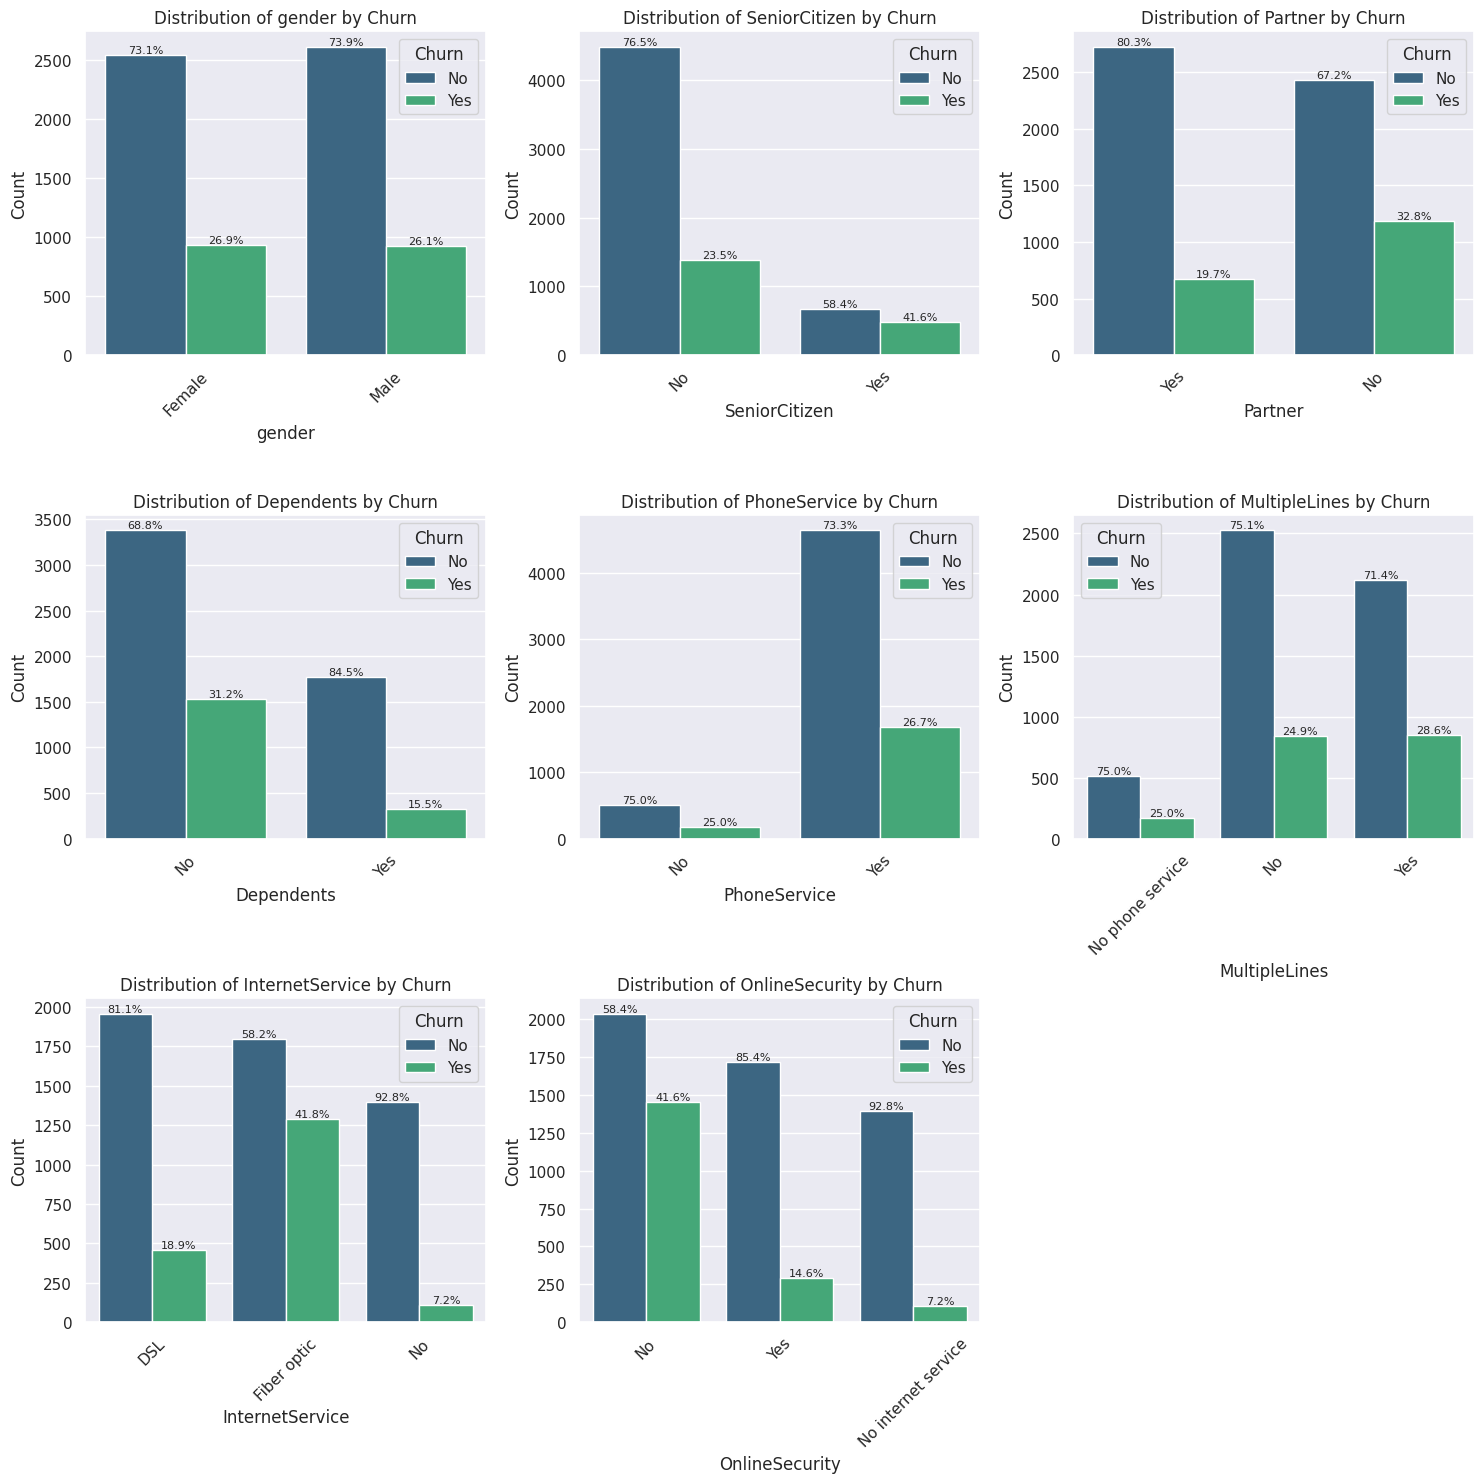

In [16]:
import math
import numpy as np


cat_cols = [col for col in df.select_dtypes(include=["object"]).columns if col != target_col]

cat_features_for_plotting = cat_cols

selected_cat_features = cat_features_for_plotting[:8]

num_features_to_plot = len(selected_cat_features)
num_cols_subplot = 3
num_rows_subplot = math.ceil(num_features_to_plot / num_cols_subplot)

fig, axes = plt.subplots(num_rows_subplot, num_cols_subplot, figsize=(15, 5 * num_rows_subplot))
axes = axes.flatten()

for i, col in enumerate(selected_cat_features):
    ax = axes[i]
    sns.countplot(data=df, x=col, hue=target_col, palette='viridis', ax=ax)
    ax.set_title(f'Distribution of {col} by {target_col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

    total_counts_per_x_category = df[col].value_counts()

    for container in ax.containers:
        for j, bar in enumerate(container):
            height = bar.get_height()
            if height == 0: continue

            x_coord = bar.get_x() + bar.get_width() / 2
            tick_labels = ax.get_xticks()
            tick_text_labels = [label.get_text() for label in ax.get_xticklabels()]

            try:
                if len(tick_labels) > 0:
                    idx = np.argmin(np.abs(tick_labels - x_coord))
                    category_label = tick_text_labels[idx]
                else:
                    category_label = ""
            except ValueError:
                category_label = ""

            if category_label in total_counts_per_x_category and total_counts_per_x_category[category_label] > 0:
                total_in_category = total_counts_per_x_category[category_label]
                percentage = f'{height / total_in_category * 100:.1f}%'
                ax.annotate(percentage, (bar.get_x() + bar.get_width() / 2, height), ha='center', va='bottom', fontsize=8)
            else:
                ax.annotate('0.0%', (bar.get_x() + bar.get_width() / 2, height), ha='center', va='bottom', fontsize=8)


for k in range(i + 1, len(axes)):
    fig.delaxes(axes[k])

plt.tight_layout()

The charts show that gender has almost no impact on churn, since the churn rates for males and females are very similar. In contrast, SeniorCitizen, Partner, Dependents, InternetService, and OnlineSecurity show a clearer association with churn: older customers and those without extra protection services tend to have higher churn rates. Customers with Fiber optic and those who do not use OnlineSecurity stand out in particular, because churn occurs more often in these groups than in the others.

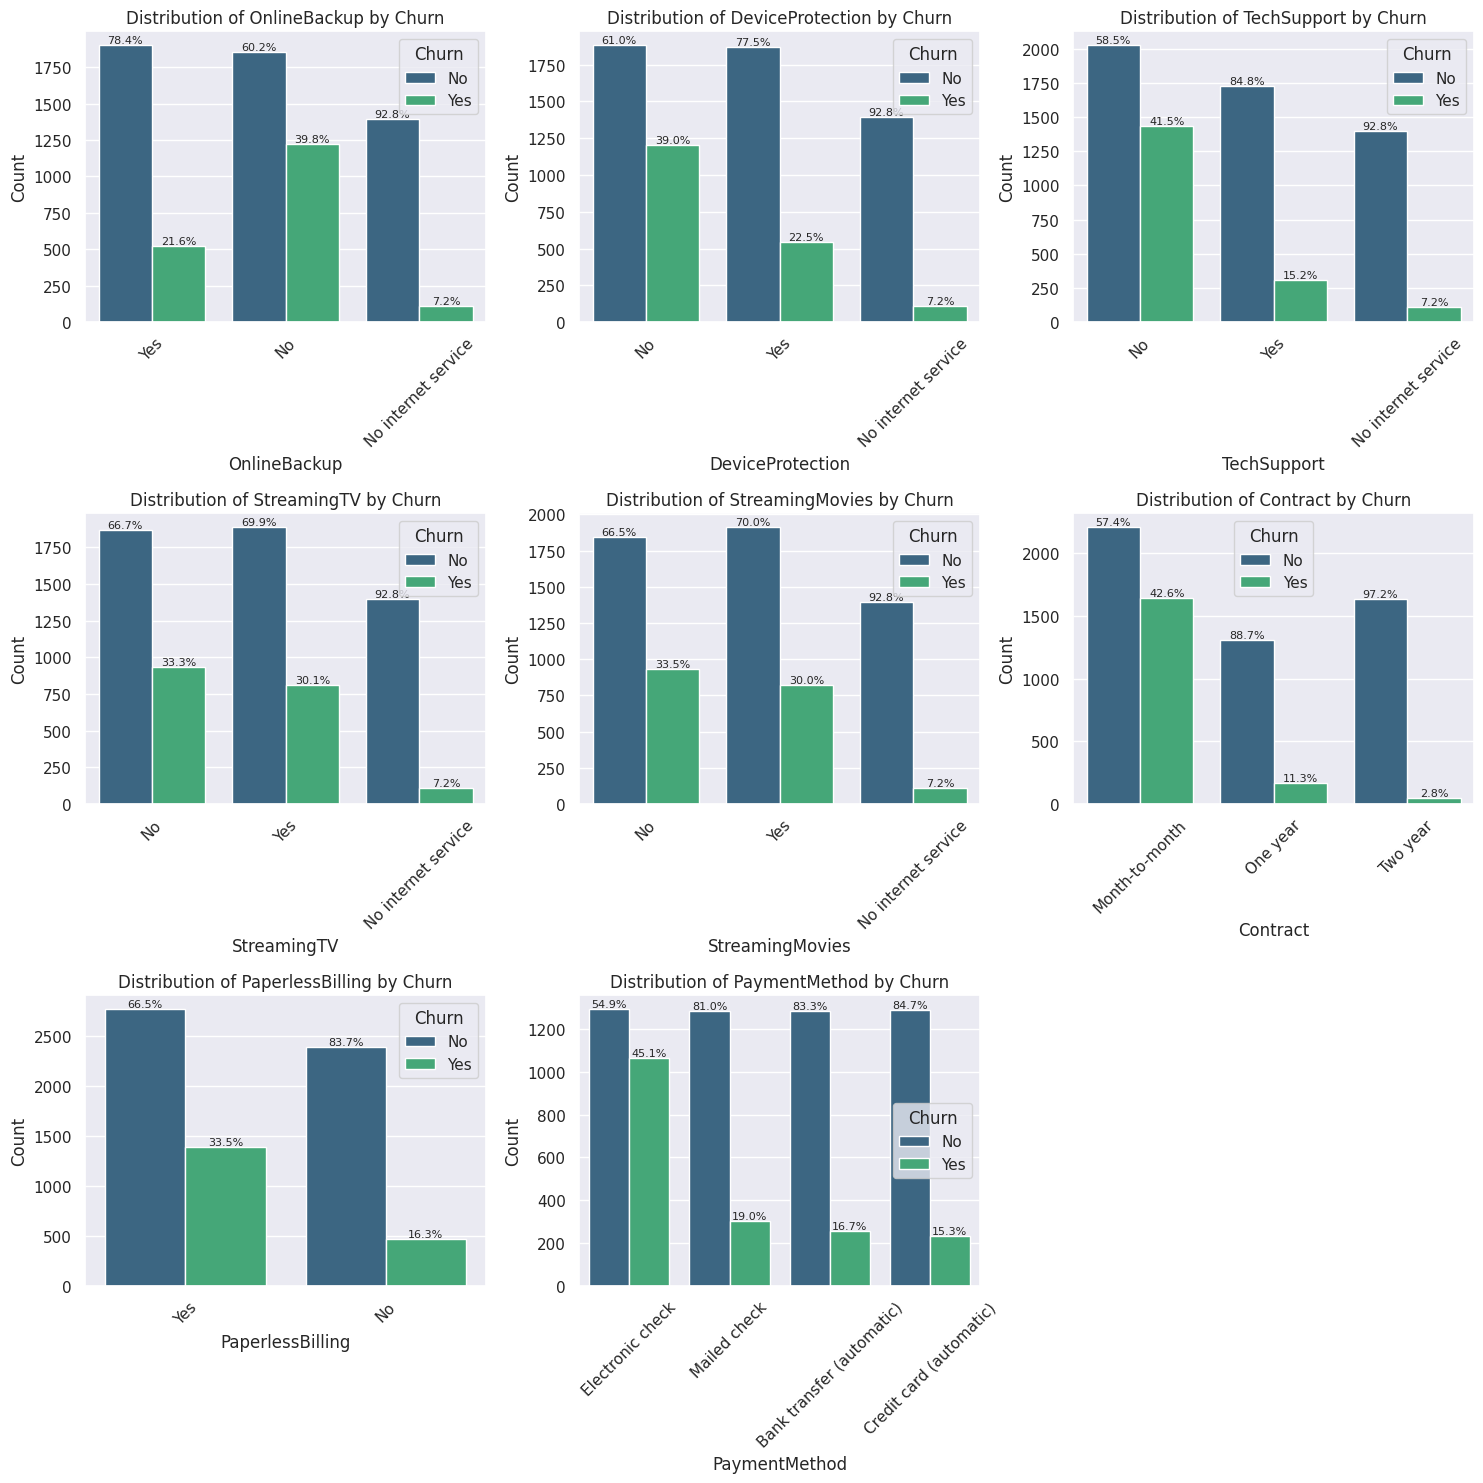

In [17]:
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


selected_cat_features = cat_features_for_plotting[-8:]

num_features_to_plot = len(selected_cat_features)
num_cols_subplot = 3
num_rows_subplot = math.ceil(num_features_to_plot / num_cols_subplot)

fig, axes = plt.subplots(num_rows_subplot, num_cols_subplot, figsize=(15, 5 * num_rows_subplot))
axes = axes.flatten()

for i, col in enumerate(selected_cat_features):
    ax = axes[i]
    sns.countplot(data=df, x=col, hue=target_col, palette='viridis', ax=ax)
    ax.set_title(f'Distribution of {col} by {target_col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

    total_counts_per_x_category = df[col].value_counts()

    for container in ax.containers:
        for j, bar in enumerate(container):
            height = bar.get_height()
            if height == 0: continue

            x_coord = bar.get_x() + bar.get_width() / 2
            tick_labels = ax.get_xticks()
            tick_text_labels = [label.get_text() for label in ax.get_xticklabels()]

            try:
                if len(tick_labels) > 0:
                    idx = np.argmin(np.abs(tick_labels - x_coord))
                    category_label = tick_text_labels[idx]
                else:
                    category_label = ""
            except ValueError:
                category_label = ""

            if category_label in total_counts_per_x_category and total_counts_per_x_category[category_label] > 0:
                total_in_category = total_counts_per_x_category[category_label]
                percentage = f'{height / total_in_category * 100:.1f}%'
                ax.annotate(percentage, (bar.get_x() + bar.get_width() / 2, height), ha='center', va='bottom', fontsize=8)
            else:
                ax.annotate('0.0%', (bar.get_x() + bar.get_width() / 2, height), ha='center', va='bottom', fontsize=8)

for k in range(i + 1, len(axes)):
    fig.delaxes(axes[k])

plt.tight_layout()
plt.show()

The charts show that churn is strongly influenced by service-related and contract-related factors. The highest churn appears among customers with a Month-to-month contract, as well as those using PaperlessBilling and paying by Electronic check. In contrast, having additional services such as OnlineBackup, DeviceProtection, and TechSupport is associated with lower churn risk, while the absence of these services is more common among customers who leave the company.

### Mutual Information

In [18]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd
import numpy as np


all_feature_cols = [col for col in df.columns if col != target_col]

X_mi = df[all_feature_cols].copy()
y_mi_encoded = df[target_col].map({'No': 0, 'Yes': 1}).values


cat_features_in_X_mi = X_mi.select_dtypes(include=['object']).columns.tolist()
num_features_in_X_mi = X_mi.select_dtypes(include=['int64', 'float64']).columns.tolist()

processed_features = []
discrete_features_mask = []

for col in all_feature_cols:
    if col in cat_features_in_X_mi:
        encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        encoded_col = encoder.fit_transform(X_mi[[col]])
        processed_features.append(encoded_col)
        discrete_features_mask.append(True)
    elif col in num_features_in_X_mi:
        processed_features.append(X_mi[[col]].values)
        discrete_features_mask.append(False)

X_processed = np.hstack(processed_features)

mi_scores_all = mutual_info_classif(X_processed, y_mi_encoded, discrete_features=discrete_features_mask)

mi_series_all = pd.Series(mi_scores_all, index=all_feature_cols)
mi_series_all = mi_series_all.sort_values(ascending=False)



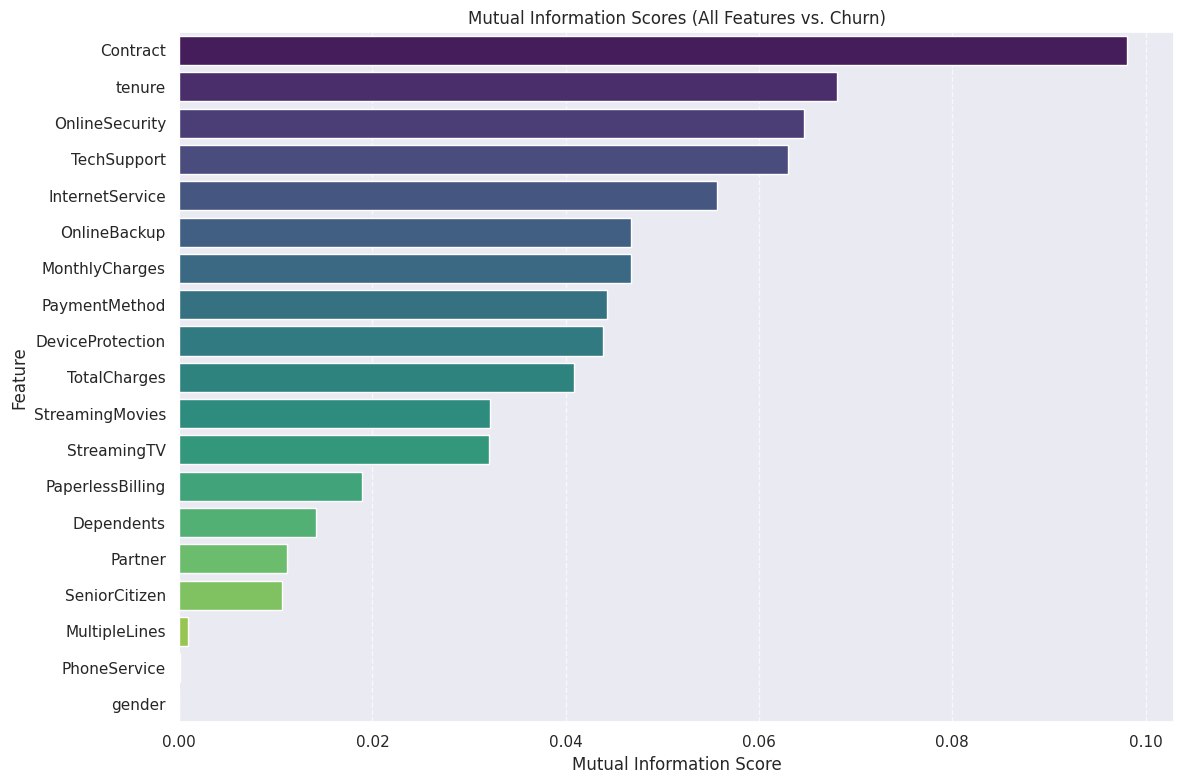

In [19]:
plt.figure(figsize=(12, 8))
sns.barplot(x=mi_series_all.values, y=mi_series_all.index, hue=mi_series_all.index, palette='viridis')
plt.title('Mutual Information Scores (All Features vs. Churn)')
plt.xlabel('Mutual Information Score')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

The mutual information results show that Contract, tenure, OnlineSecurity, TechSupport, and InternetService have the strongest relationship with churn. This means contract type, customer tenure, and the presence of additional protection services are the most informative features for predicting churn. In contrast, gender, PhoneService, and MultipleLines contain very little useful information for the model, so their contribution to churn prediction is minimal.After analyzing feature importance, gender and PhoneService were removed from the dataset since their contribution to churn prediction was minimal. This reduction helps simplify the model, reduce noise, and keep the focus on the most informative variables.

In [20]:
df.drop(columns=['gender', 'PhoneService'], inplace=True)

### Log Transformation

In [21]:
df['TotalCharges'] = np.log1p(df['TotalCharges'])


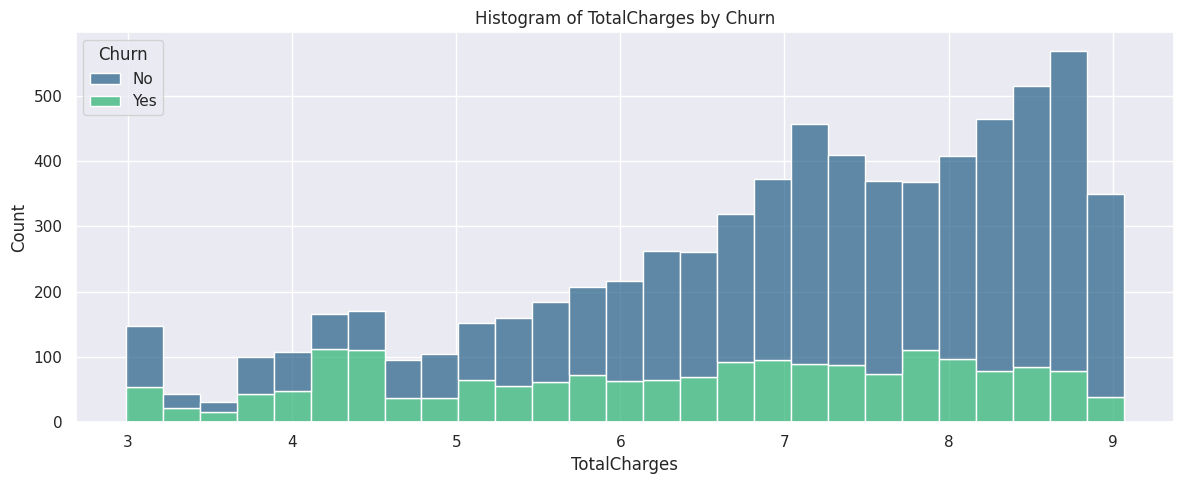

In [22]:
plt.figure(figsize=(12, 5))

sns.histplot(data=df, x='TotalCharges', hue='Churn', palette='viridis', multiple='stack')
plt.title('Histogram of TotalCharges by Churn')
plt.xlabel('TotalCharges')
plt.ylabel('Count')

plt.tight_layout()

## Bivariate Analysis

### Churn Rate by Categorical Features

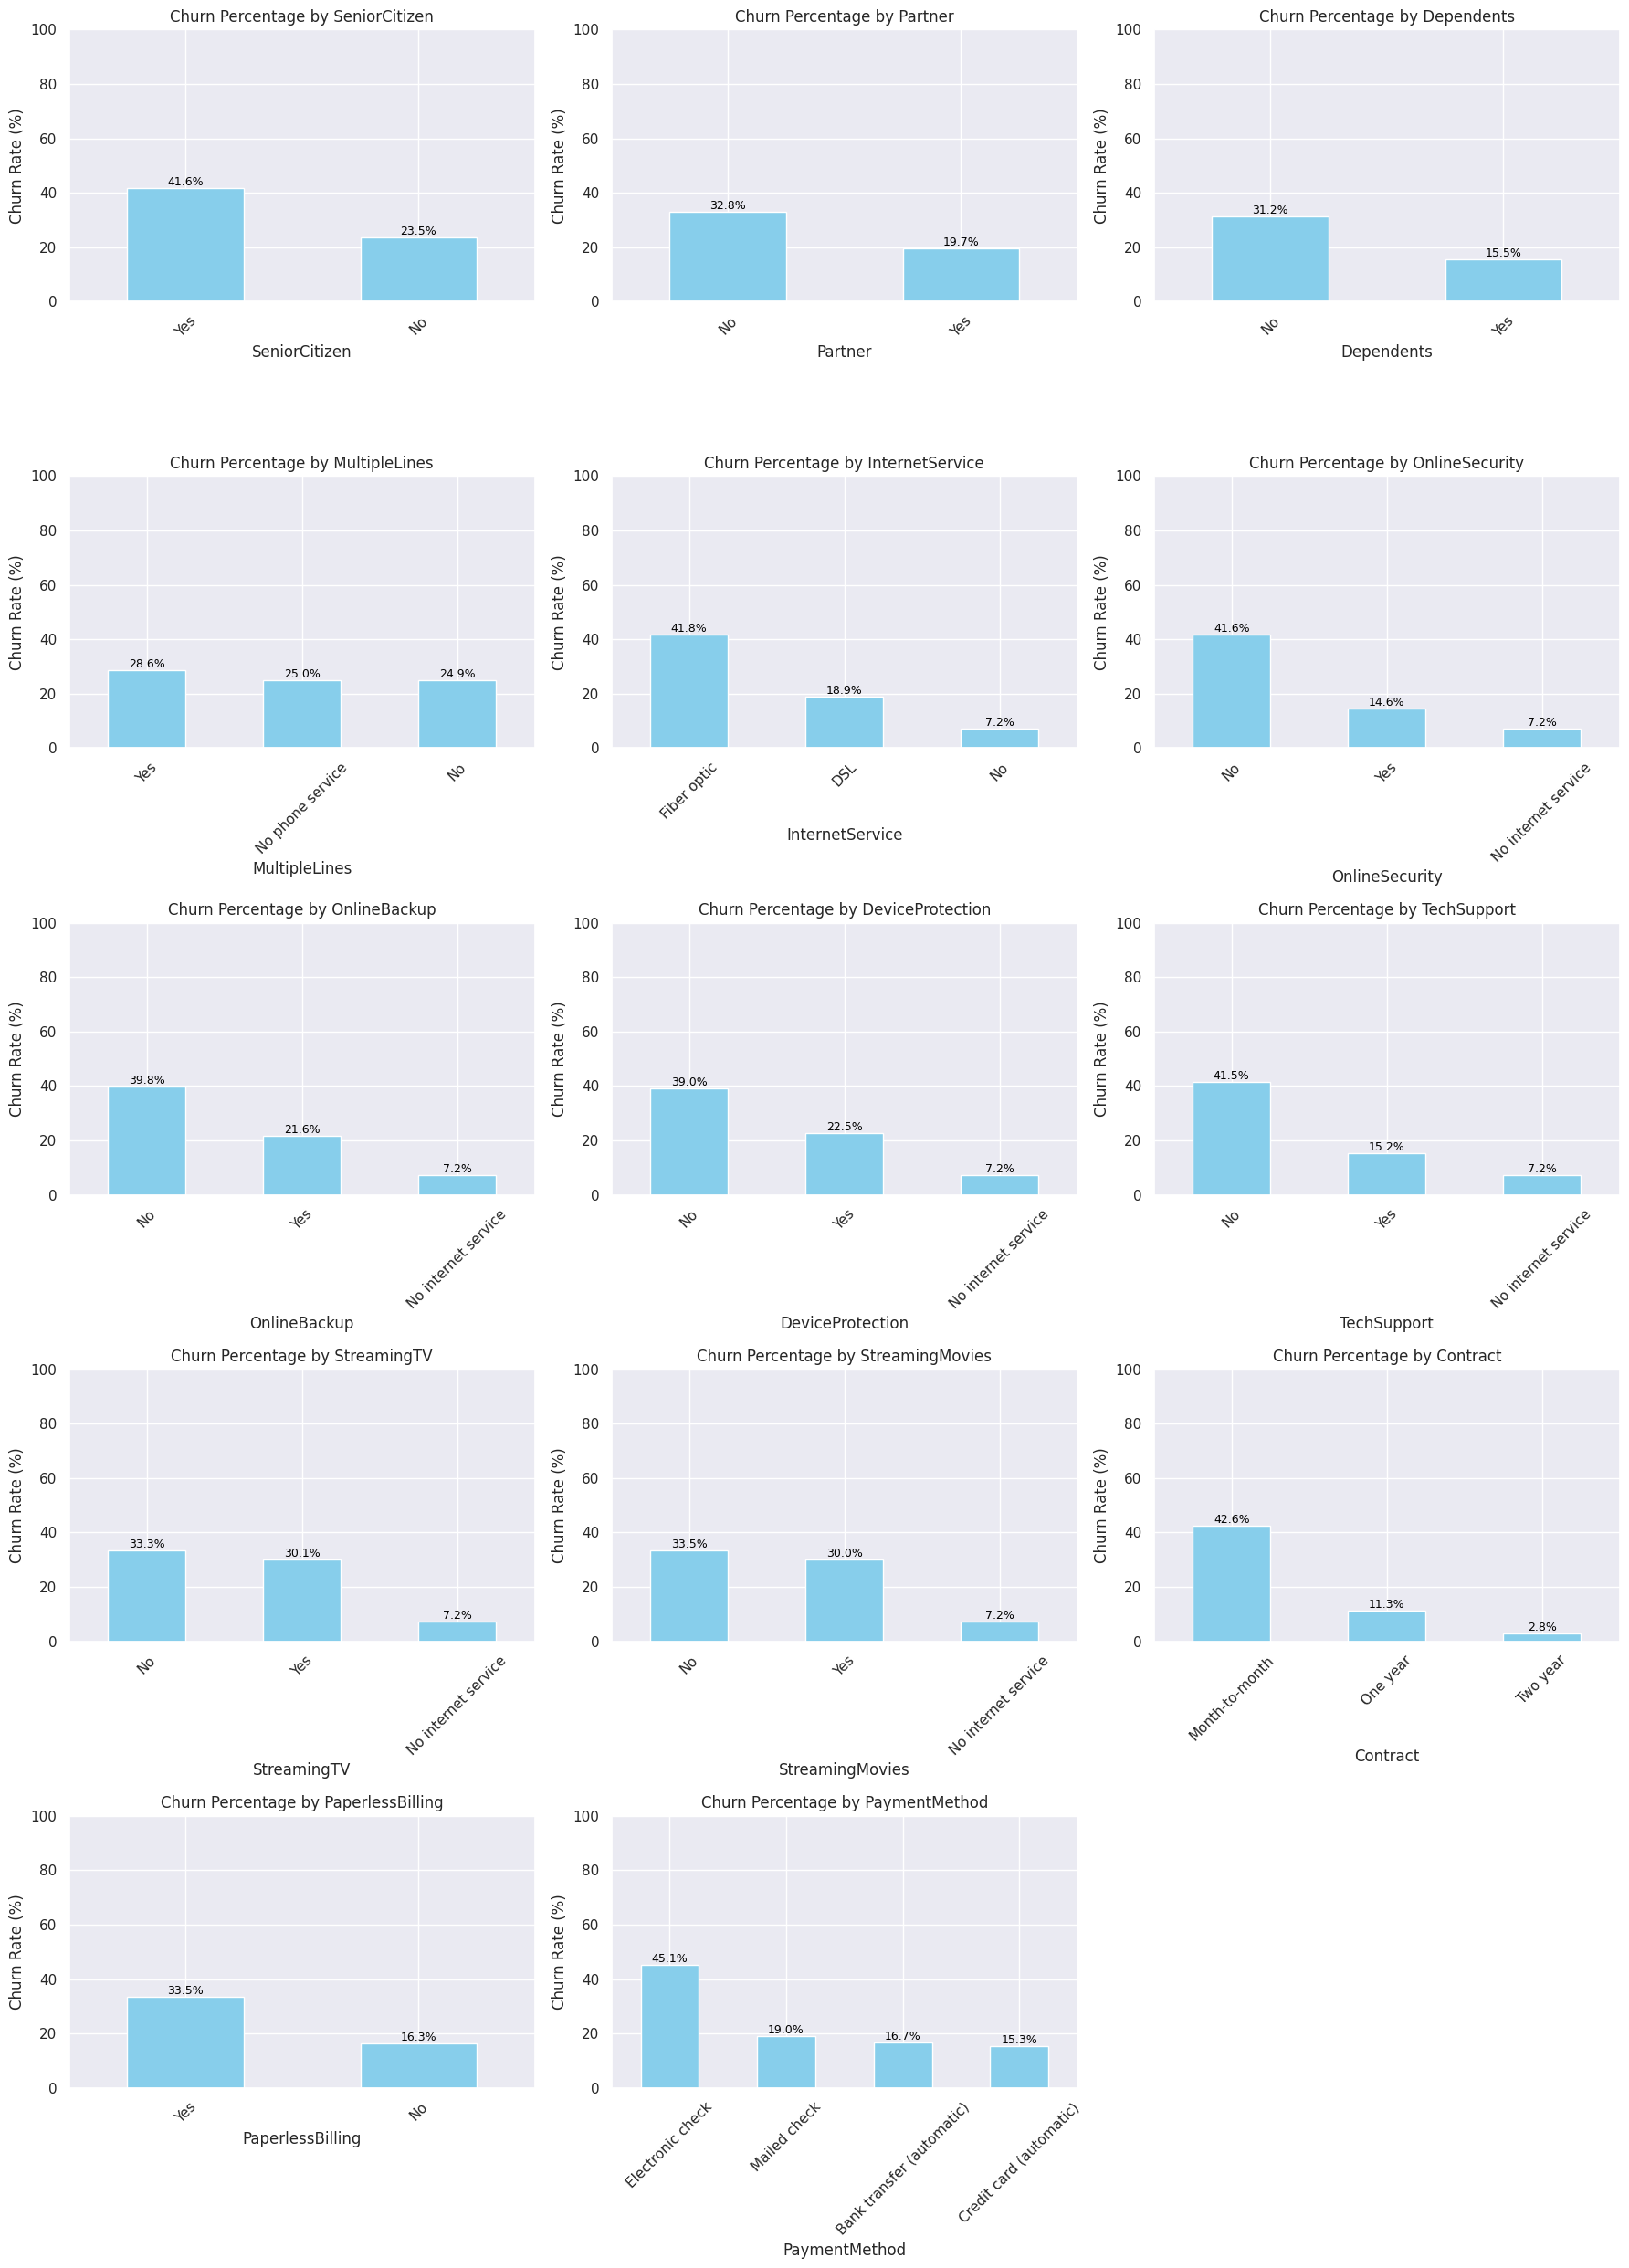

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

cat_cols_updated = [col for col in df.select_dtypes(include=["object"]).columns if col not in [target_col, 'gender', 'PhoneService']]

num_features_to_plot = len(cat_cols_updated)
num_cols_subplot = 3
num_rows_subplot = (num_features_to_plot + num_cols_subplot - 1) // num_cols_subplot

fig, axes = plt.subplots(num_rows_subplot, num_cols_subplot, figsize=(18, 5 * num_rows_subplot))
axes = axes.flatten() if num_rows_subplot > 1 or num_cols_subplot > 1 else [axes]

for i, col in enumerate(cat_cols_updated):
    churn_percentages = df.groupby(col)[target_col].value_counts(normalize=True).unstack().fillna(0)
    churn_rate = churn_percentages['Yes'] * 100

    # Plotting
    ax = axes[i]
    churn_rate.sort_values(ascending=False).plot(kind='bar', ax=ax, color='skyblue')
    ax.set_title(f'Churn Percentage by {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Churn Rate (%)')
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0, 100)

    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, color='black')

for k in range(i + 1, len(axes)):
    fig.delaxes(axes[k])

plt.tight_layout()

These charts confirm that the highest churn occurs among customers with a Month-to-month contract, Electronic check as the payment method, and PaperlessBilling. Churn is also high among customers without OnlineSecurity, TechSupport, OnlineBackup, and DeviceProtection, which highlights the importance of additional services for customer retention. The lowest churn appears among customers with longer contracts (One year, Two year) and those with stronger service protection and support

### Categorical Feature Relationships

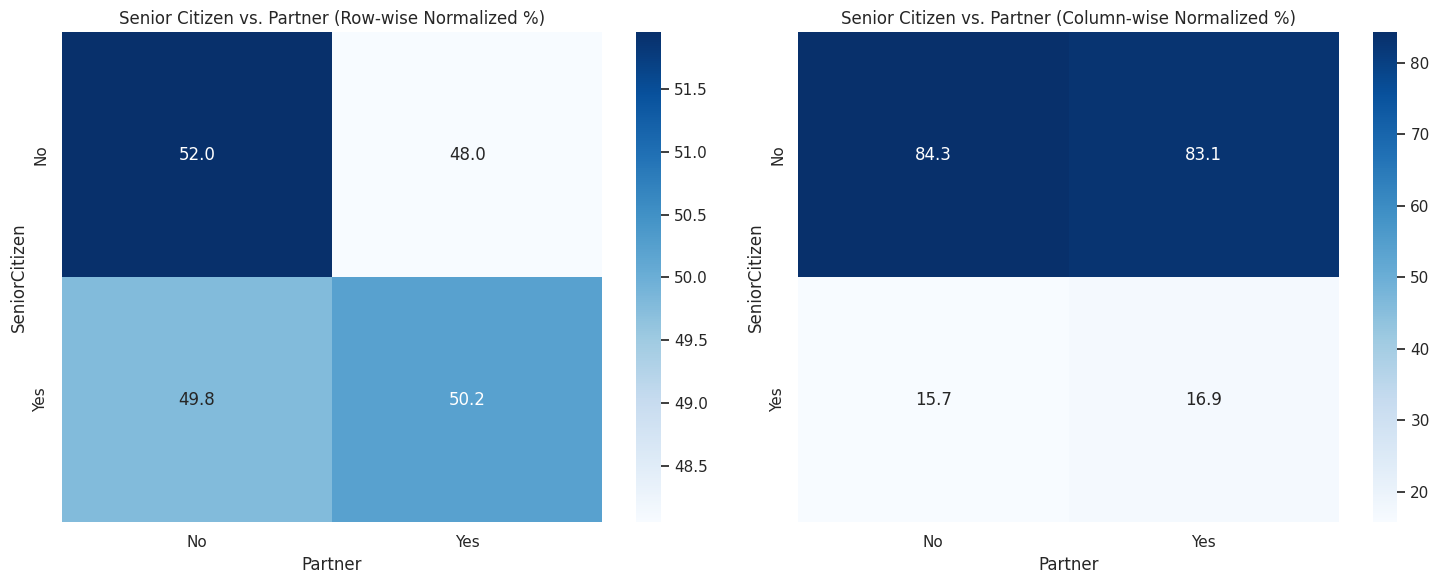

In [39]:
cross_tab = pd.crosstab(df['SeniorCitizen'], df['Partner'])

row_wise_norm = cross_tab.div(cross_tab.sum(axis=1), axis=0) * 100

col_wise_norm = cross_tab.div(cross_tab.sum(axis=0), axis=1) * 100

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.heatmap(row_wise_norm, annot=True, fmt='.1f', cmap='Blues', cbar=True)
plt.title('Senior Citizen vs. Partner (Row-wise Normalized %)')
plt.xlabel('Partner')
plt.ylabel('SeniorCitizen')

plt.subplot(1, 2, 2)
sns.heatmap(col_wise_norm, annot=True, fmt='.1f', cmap='Blues', cbar=True)
plt.title('Senior Citizen vs. Partner (Column-wise Normalized %)')
plt.xlabel('Partner')
plt.ylabel('SeniorCitizen')

plt.tight_layout()

The conclusion is that SeniorCitizen and Partner appear to have a very weak or almost no relationship.

#Preprocessing

In [25]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

In [26]:
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

In [27]:
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [col for col in X_train.columns if col not in numeric_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

In [28]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

#Model

## Baseline Model

In [29]:
from sklearn.dummy import DummyClassifier

In [30]:
dummy_classifier = DummyClassifier(strategy="uniform")

In [31]:
dummy_classifier.fit(X_train_processed, y_train)
dummy_predictions = dummy_classifier.predict(X_test_processed)

In [32]:
from sklearn.metrics import accuracy_score, f1_score

dummy_accuracy = accuracy_score(y_test, dummy_predictions)
dummy_f1 = f1_score(y_test, dummy_predictions, pos_label='Yes')

print(f"Dummy Classifier Accuracy: {dummy_accuracy:.4f}")
print(f"Dummy Classifier F1-score: {dummy_f1:.4f}")

Dummy Classifier Accuracy: 0.5007
Dummy Classifier F1-score: 0.3458


## Logistic Regression

### Hyperparameter Tuning with Cross-Validation

In [33]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import accuracy_score, f1_score


log_reg_cv_model = LogisticRegressionCV(
    solver='liblinear',
    cv=10,
    scoring='f1',
    n_jobs=-1,
    class_weight='balanced'
)

log_reg_cv_model.fit(X_train_processed, y_train)

log_reg_cv_predictions = log_reg_cv_model.predict(X_test_processed)

log_reg_cv_accuracy = accuracy_score(y_test, log_reg_cv_predictions)
log_reg_cv_f1 = f1_score(y_test, log_reg_cv_predictions, pos_label='Yes')

print(f"Logistic Regression CV Accuracy: {log_reg_cv_accuracy:.4f}")
print(f"Logistic Regression CV F1-score: {log_reg_cv_f1:.4f}")

Logistic Regression CV Accuracy: 0.7639
Logistic Regression CV F1-score: 0.6445


### Model Performance Analysis

#####Classification_report

In [34]:
from sklearn.metrics import classification_report

print("Classification Report for Logistic Regression CV:\n")
print(classification_report(y_test, log_reg_cv_predictions))

Classification Report for Logistic Regression CV:

              precision    recall  f1-score   support

          No       0.92      0.75      0.82      1031
         Yes       0.54      0.81      0.64       371

    accuracy                           0.76      1402
   macro avg       0.73      0.78      0.73      1402
weighted avg       0.82      0.76      0.78      1402



The Logistic Regression CV model achieves moderate overall performance with 76% accuracy, but it is much better at identifying the Yes class in terms of recall than precision. This means it catches most positive cases, but it also produces a relatively high number of false positives, so it is more suitable when missing a Yes is costlier than flagging some extra ones

####Confusion_matrix

Text(66.25, 0.5, 'True Label')

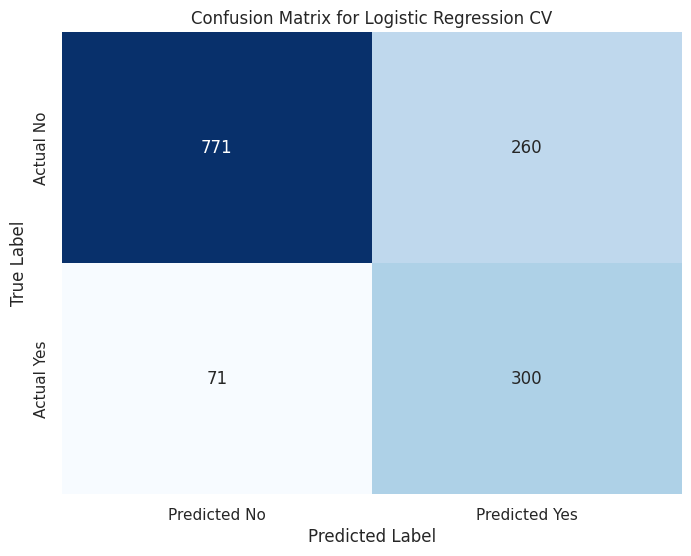

In [35]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, log_reg_cv_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
plt.title('Confusion Matrix for Logistic Regression CV')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

####Feature Importances

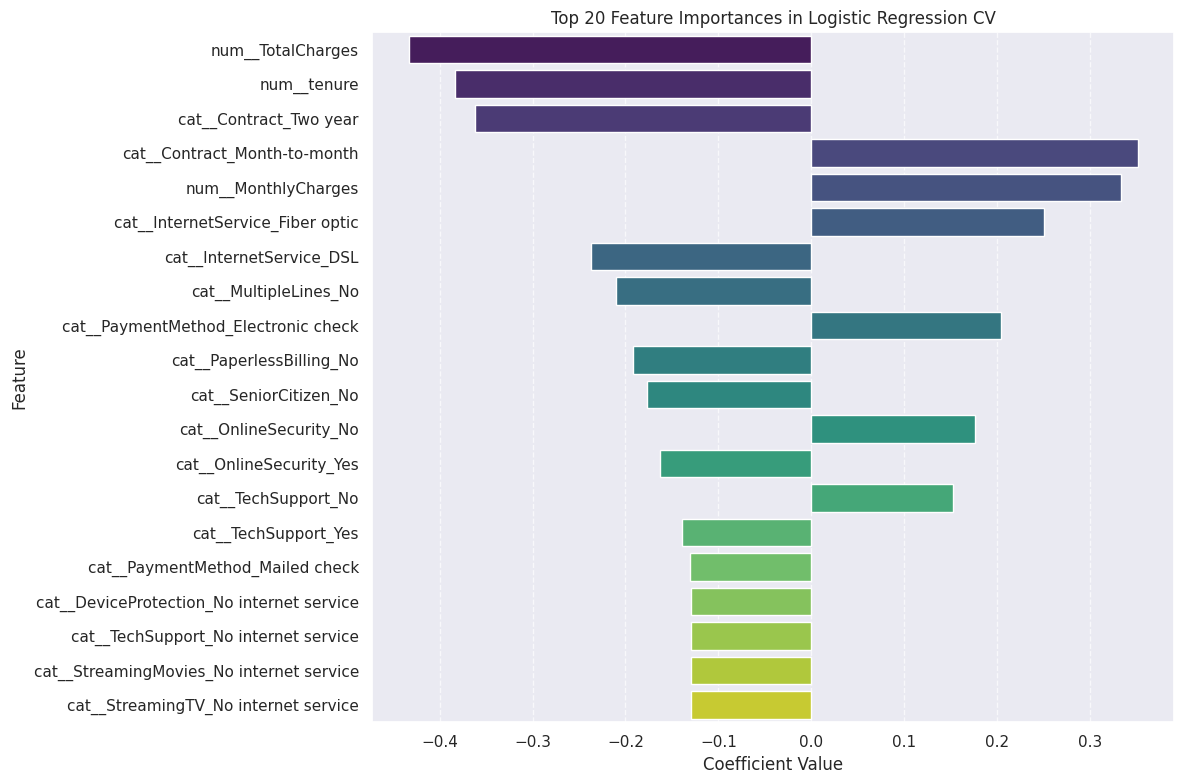

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

feature_names = preprocessor.get_feature_names_out()
coefficients = log_reg_cv_model.coef_[0]

feature_importance = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

feature_importance['Abs_Coefficient'] = abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values(by='Abs_Coefficient', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance.head(20), hue='Feature', palette='viridis')
plt.title('Top 20 Feature Importances in Logistic Regression CV')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()